In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

In [97]:
load_dotenv()

True

In [98]:
df = pd.read_csv(os.getenv('csv_path'))

In [99]:
pd.options.display.max_columns=False
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
for col in df.columns:
    print(f"{col} - {df[col].nunique()}")

id_songs - 95837
name_song - 85427
popularity_songs - 94
duration_ms - 44685
explicit - 2
id_artists - 18009
release_date - 10436
danceability - 996
energy - 1928
key - 12
loudness - 19919
mode - 2
speechiness - 1648
acousticness - 3946
instrumentalness - 5356
liveness - 1713
valence - 1595
tempo - 58312
time_signature - 5
followers - 11585
genres - 3153
name_artists - 17662
popularity_artists - 93


In [103]:
drop_cols = [
    'id_songs',
    'name_song',
    'id_artists',
    'name_artists',
    'genres',
    'release_date',
    'popularity_songs',
    'followers',
    'popularity_artists',
    'explicit',
    'key',
    'mode',
    'time_signature'
]

df.drop(columns=drop_cols, inplace=True)

In [104]:
df

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,161427,0.563,0.1840,-13.757,0.0512,0.993,0.000016,0.3250,0.654,133.088
1,223440,0.427,0.1800,-15.375,0.0670,0.989,0.000000,0.1280,0.431,78.459
2,208267,0.511,0.2060,-15.514,0.0592,0.995,0.000000,0.4180,0.481,70.443
3,161933,0.676,0.4670,-12.393,0.1650,0.991,0.000000,0.2190,0.726,129.775
4,167973,0.650,0.2980,-13.806,0.1380,0.991,0.000000,0.3730,0.844,75.950
...,...,...,...,...,...,...,...,...,...,...
95832,174800,0.674,0.5680,-6.356,0.0408,0.116,0.000000,0.1650,0.640,166.107
95833,265846,0.528,0.6730,-3.639,0.0314,0.143,0.000000,0.0989,0.297,130.066
95834,82500,0.609,0.0172,-28.573,0.1180,0.996,0.973000,0.1080,0.890,68.619
95835,185250,0.562,0.0331,-25.551,0.1030,0.996,0.961000,0.1110,0.386,63.696


In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

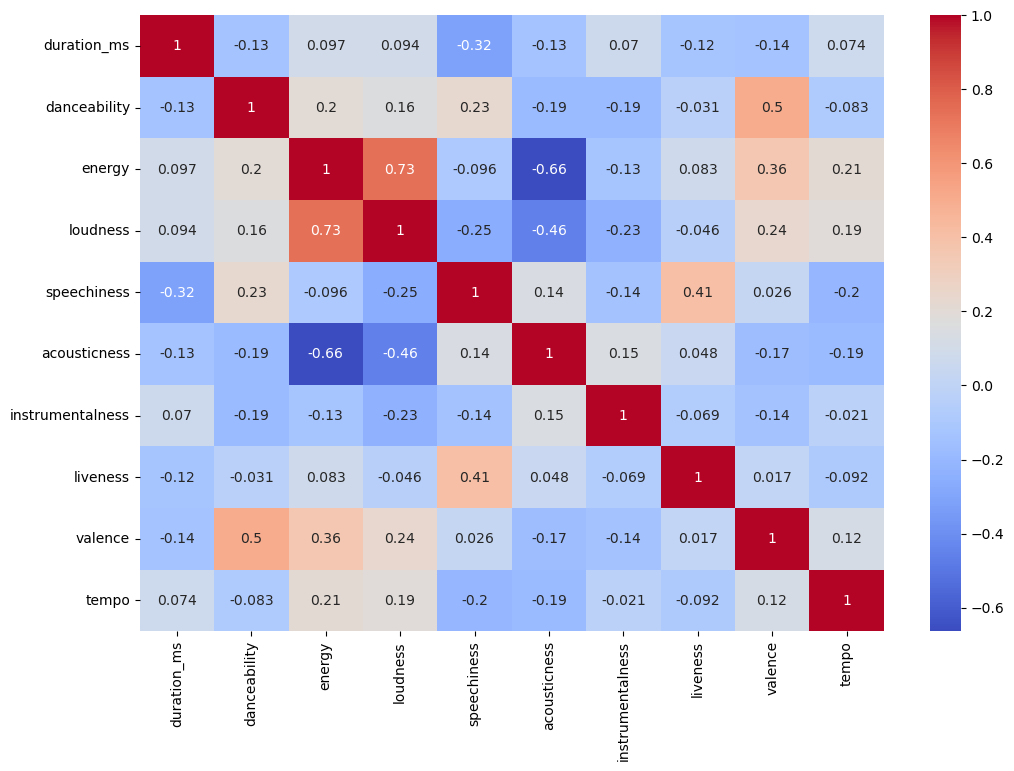

In [106]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.show()

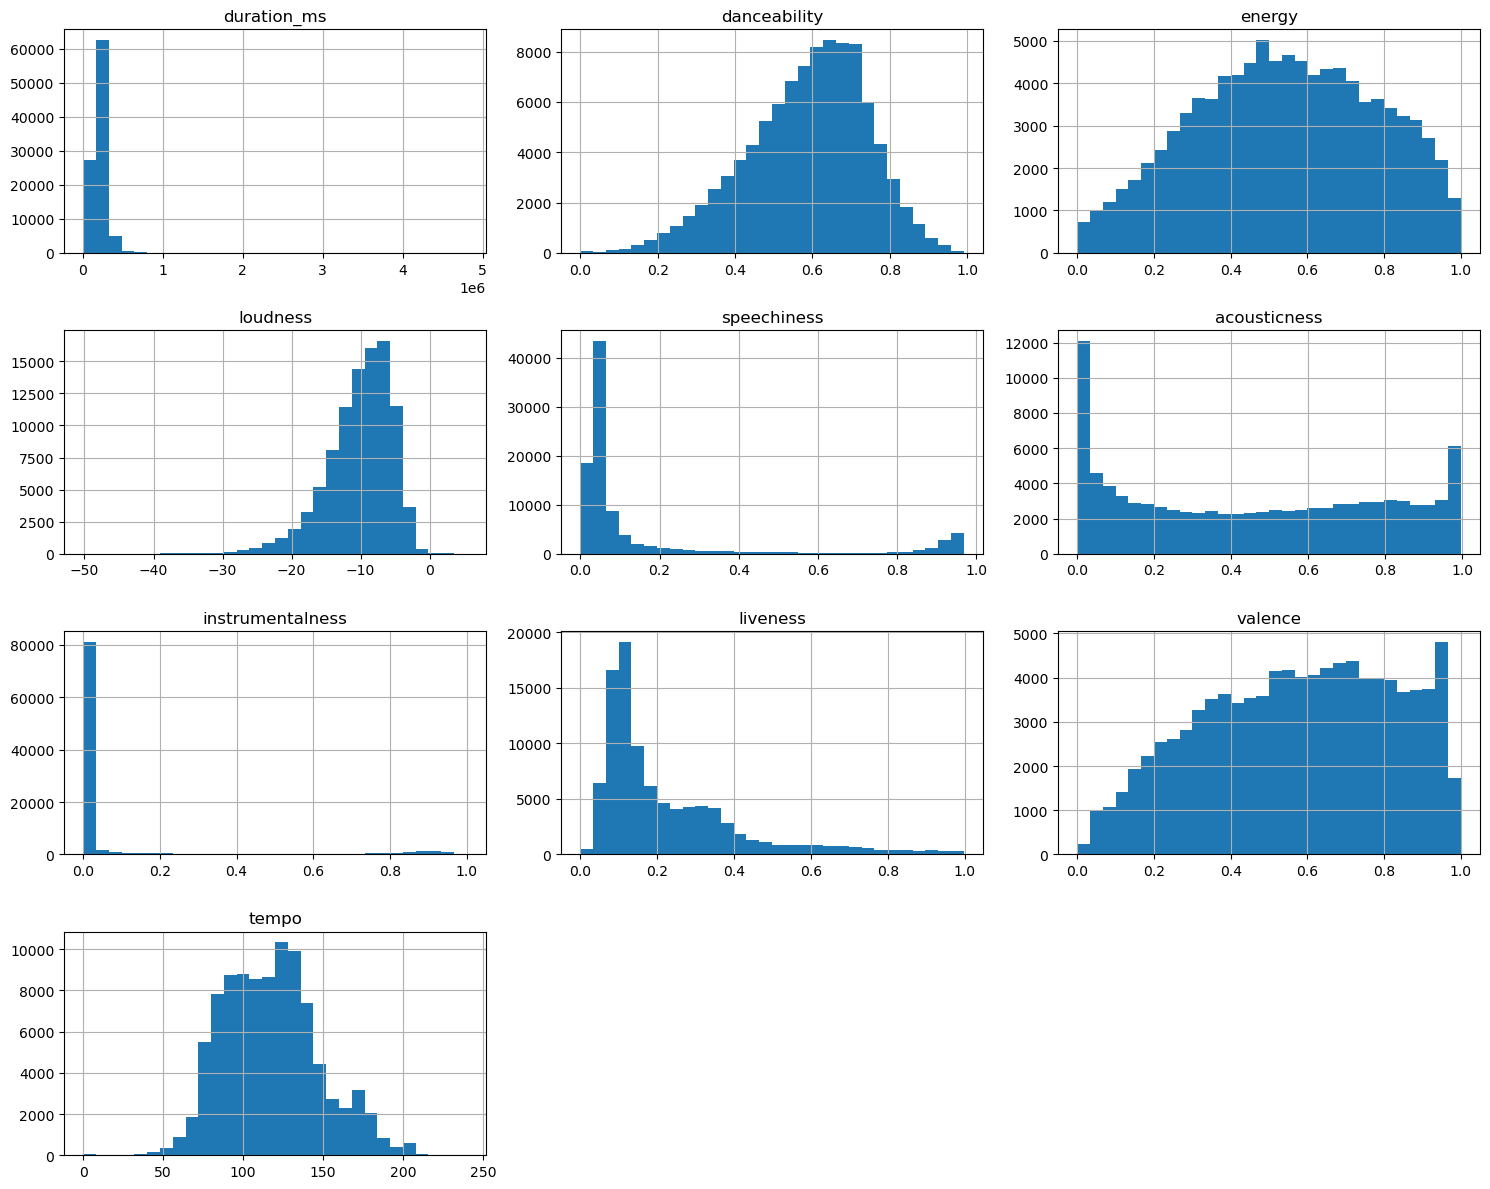

In [107]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

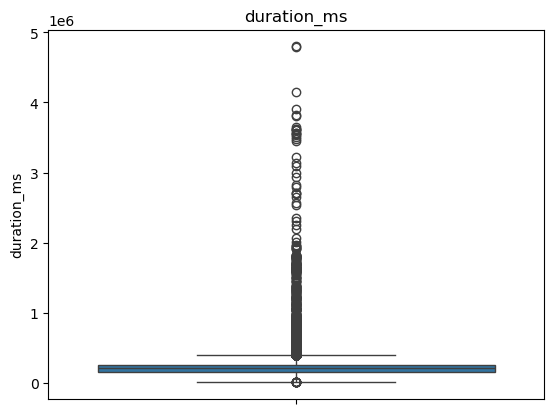

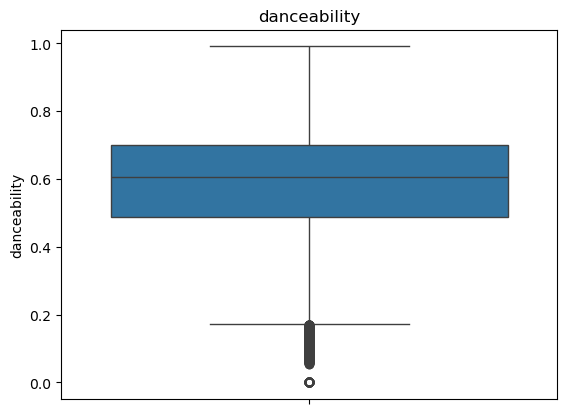

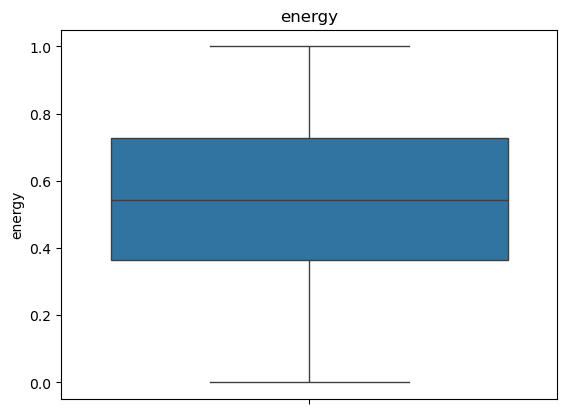

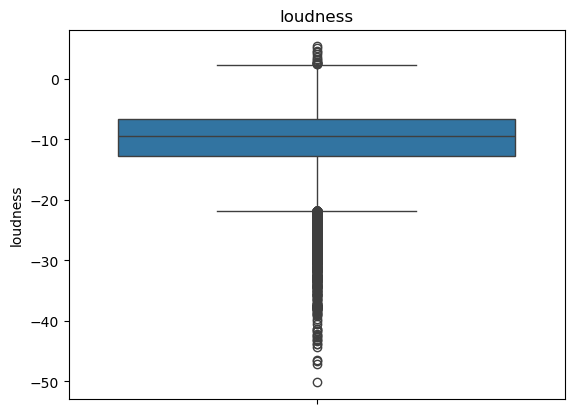

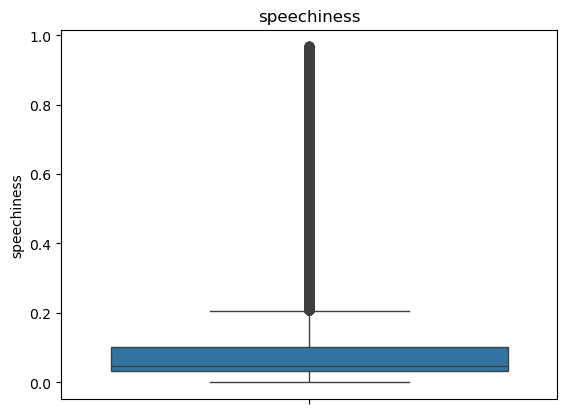

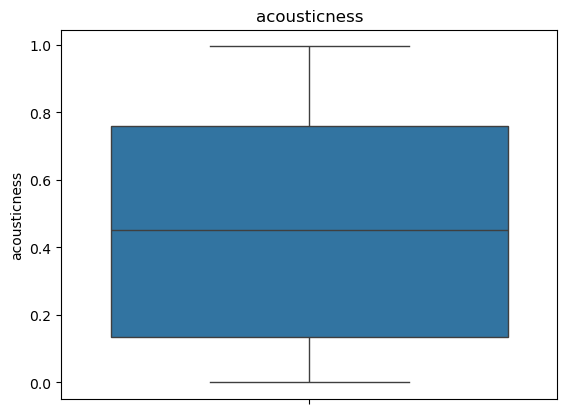

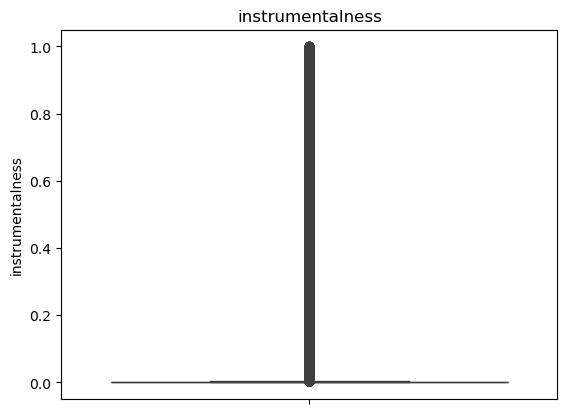

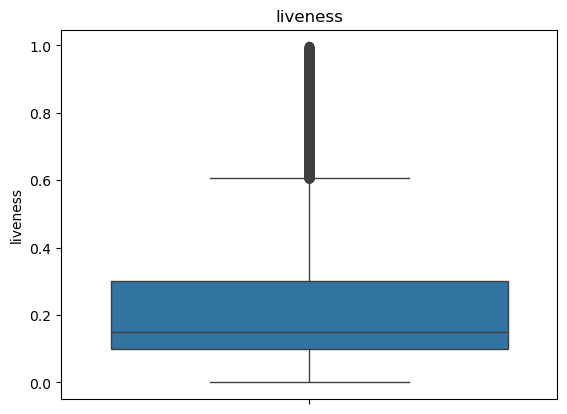

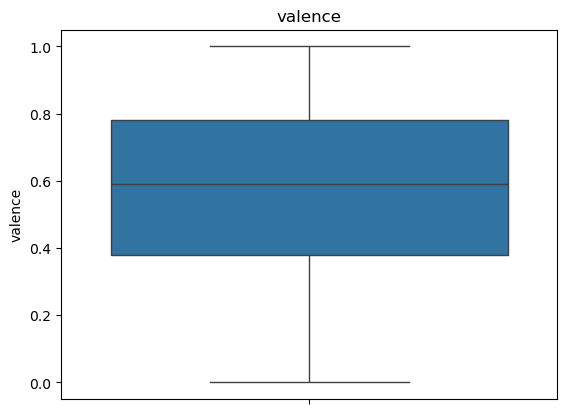

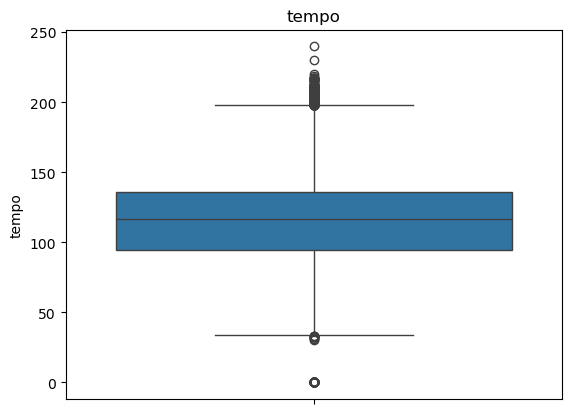

In [108]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()

In [109]:
df.to_csv('cleaned_dataset.csv', index=False)